In [2]:
import openeo

connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Authenticated using refresh token.


In [7]:
aoi = {
    "type": "Polygon",
    # Paste koordinat yang didapat 
    "coordinates":
        [
            [
              117.58812764552601,
              4.133326974398287
            ],
            [
              117.75161907303544,
              4.133326974398287
            ],
            [
              117.75161907303544,
              3.971832859595736
            ],
            [
              117.58812764552601,
              3.971832859595736
            ],
            [
              117.58812764552601,
              4.133326974398287
            ]
    ]
}

s5post = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2025-08-31", "2026-08-31"],
    spatial_extent={
        "west": 117.58812764552601,
        "south": 3.971832859595736,
        "east": 117.75161907303544,
        "north": 4.133326974398287
    },
    # Disesuaikan dengan data yang dibutuhkan
    bands=["CO"],
)

# Agregasi harian agar tidak ada lebih dari satu data per hari
s5p_co_daily = s5post.aggregate_temporal_period(reducer="mean", period="day")

# Agregasi spasial untuk menghasilkan rata-rata time series per AOI
s5p_co_aoi = s5p_co_daily.aggregate_spatial(reducer="mean", geometries=aoi)

In [6]:
job = s5post.execute_batch(title="NO2 in Nunukan", outputfile="NO2DiNunukan.nc")

0:00:00 Job 'j-2609111246254e8cb05cc0ca6fffc983': send 'start'
0:00:05 Job 'j-2609111246254e8cb05cc0ca6fffc983': queued (progress 0%)
0:00:10 Job 'j-2609111246254e8cb05cc0ca6fffc983': queued (progress 0%)
0:00:17 Job 'j-2609111246254e8cb05cc0ca6fffc983': queued (progress 0%)
0:00:25 Job 'j-2609111246254e8cb05cc0ca6fffc983': queued (progress 0%)
0:00:35 Job 'j-2609111246254e8cb05cc0ca6fffc983': queued (progress 0%)
0:00:48 Job 'j-2609111246254e8cb05cc0ca6fffc983': queued (progress 0%)
0:01:03 Job 'j-2609111246254e8cb05cc0ca6fffc983': queued (progress 0%)
0:01:23 Job 'j-2609111246254e8cb05cc0ca6fffc983': running (progress N/A)
0:01:47 Job 'j-2609111246254e8cb05cc0ca6fffc983': running (progress N/A)
0:02:17 Job 'j-2609111246254e8cb05cc0ca6fffc983': running (progress N/A)
0:02:54 Job 'j-2609111246254e8cb05cc0ca6fffc983': running (progress N/A)
0:03:41 Job 'j-2609111246254e8cb05cc0ca6fffc983': running (progress N/A)
0:04:40 Job 'j-2609111246254e8cb05cc0ca6fffc983': finished (progress 100%)


In [8]:
job = s5post.execute_batch(title="CO in Nunukan", outputfile="CODiNunukan.nc")

0:00:00 Job 'j-26091112515446bab4e004674262f269': send 'start'
0:00:05 Job 'j-26091112515446bab4e004674262f269': queued (progress 0%)
0:00:10 Job 'j-26091112515446bab4e004674262f269': queued (progress 0%)
0:00:17 Job 'j-26091112515446bab4e004674262f269': queued (progress 0%)
0:00:25 Job 'j-26091112515446bab4e004674262f269': queued (progress 0%)
0:00:35 Job 'j-26091112515446bab4e004674262f269': queued (progress 0%)
0:00:48 Job 'j-26091112515446bab4e004674262f269': queued (progress 0%)
0:01:03 Job 'j-26091112515446bab4e004674262f269': running (progress N/A)
0:01:23 Job 'j-26091112515446bab4e004674262f269': running (progress N/A)
0:01:47 Job 'j-26091112515446bab4e004674262f269': running (progress N/A)
0:02:17 Job 'j-26091112515446bab4e004674262f269': running (progress N/A)
0:02:55 Job 'j-26091112515446bab4e004674262f269': running (progress N/A)
0:03:42 Job 'j-26091112515446bab4e004674262f269': finished (progress 100%)


In [4]:
job = s5post.execute_batch(title="SO2 in Nunukan", outputfile="SO2DiNunukan.nc")

0:00:00 Job 'j-2609111240534818ae5435cdfce9c8a4': send 'start'
0:00:06 Job 'j-2609111240534818ae5435cdfce9c8a4': queued (progress 0%)
0:00:11 Job 'j-2609111240534818ae5435cdfce9c8a4': queued (progress 0%)
0:00:18 Job 'j-2609111240534818ae5435cdfce9c8a4': queued (progress 0%)
0:00:26 Job 'j-2609111240534818ae5435cdfce9c8a4': queued (progress 0%)
0:00:36 Job 'j-2609111240534818ae5435cdfce9c8a4': queued (progress 0%)
0:00:49 Job 'j-2609111240534818ae5435cdfce9c8a4': queued (progress 0%)
0:01:04 Job 'j-2609111240534818ae5435cdfce9c8a4': queued (progress 0%)
0:01:24 Job 'j-2609111240534818ae5435cdfce9c8a4': queued (progress 0%)
0:01:48 Job 'j-2609111240534818ae5435cdfce9c8a4': running (progress N/A)
0:02:18 Job 'j-2609111240534818ae5435cdfce9c8a4': running (progress N/A)
0:02:56 Job 'j-2609111240534818ae5435cdfce9c8a4': running (progress N/A)
0:03:43 Job 'j-2609111240534818ae5435cdfce9c8a4': running (progress N/A)
0:04:42 Job 'j-2609111240534818ae5435cdfce9c8a4': finished (progress 100%)


In [ ]:
import numpy as np
import pandas as pd
import netCDF4

file_path = "NO2DiNunukan.nc"
ds = netCDF4.Dataset(file_path)

# Ambil NO2 sebagai masked array, lalu ubah data kosong (masked) jadi NaN
no2 = ds.variables["NO2"][:]
no2 = np.ma.filled(no2, np.nan)

# Ambil Time
time = ds.variables["t"][:]

# Konversi waktu ke format tanggal
try:
    time_units = ds.variables["t"].units
    dates = netCDF4.num2date(time, units=time_units)
except Exception:
    dates = time  # fallback jika tidak ada units

new_dates = []
new_no2 = []

for i in range(len(dates)):
    new_date = dates[i].strftime('%Y-%m-%d')
    new_dates.append(new_date)

    daily_data = no2[i]
    if np.all(np.isnan(daily_data)):
        # Kalau seluruh data hari itu kosong, hasilnya NaN
        new_no2.append(np.nan)
    else:
        # np.nanmean mengabaikan NaN saat menghitung rata-rata
        new_no2.append(np.nanmean(daily_data))

df = pd.DataFrame({
    "date": new_dates,
    "NO2": new_no2
})

# Simpan ke CSV (NaN otomatis ditulis sebagai kosong/"" oleh pandas)
df.to_csv("NO2_Nunukan_timeseries.csv", index=False)

In [10]:
import numpy as np
import pandas as pd
import netCDF4

file_path = "SO2DiNunukan.nc"
ds = netCDF4.Dataset(file_path)

# Ambil SO2 sebagai masked array, lalu ubah data kosong (masked) jadi NaN
so2 = ds.variables["SO2"][:]
so2 = np.ma.filled(so2, np.nan)

# Ambil Time
time = ds.variables["t"][:]

# Konversi waktu ke format tanggal
try:
    time_units = ds.variables["t"].units
    dates = netCDF4.num2date(time, units=time_units)
except Exception:
    dates = time  # fallback jika tidak ada units

new_dates = []
new_so2 = []

for i in range(len(dates)):
    new_date = dates[i].strftime('%Y-%m-%d')
    new_dates.append(new_date)

    daily_data = so2[i]
    if np.all(np.isnan(daily_data)):
        # Kalau seluruh data hari itu kosong, hasilnya NaN
        new_so2.append(np.nan)
    else:
        # np.nanmean mengabaikan NaN saat menghitung rata-rata
        new_so2.append(np.nanmean(daily_data))

df = pd.DataFrame({
    "date": new_dates,
    "SO2": new_so2
})

# Simpan ke CSV (NaN otomatis ditulis sebagai kosong/"" oleh pandas)
df.to_csv("SO2_Nunukan_timeseries.csv", index=False)

In [11]:
import numpy as np
import pandas as pd
import netCDF4

file_path = "CODiNunukan.nc"
ds = netCDF4.Dataset(file_path)

# Ambil CO sebagai masked array, lalu ubah data kosong (masked) jadi NaN
co = ds.variables["CO"][:]
co = np.ma.filled(co, np.nan)

# Ambil Time
time = ds.variables["t"][:]

# Konversi waktu ke format tanggal
try:
    time_units = ds.variables["t"].units
    dates = netCDF4.num2date(time, units=time_units)
except Exception:
    dates = time  # fallback jika tidak ada units

new_dates = []
new_co = []

for i in range(len(dates)):
    new_date = dates[i].strftime('%Y-%m-%d')
    new_dates.append(new_date)

    daily_data = co[i]
    if np.all(np.isnan(daily_data)):
        # Kalau seluruh data hari itu kosong, hasilnya NaN
        new_co.append(np.nan)
    else:
        # np.nanmean mengabaikan NaN saat menghitung rata-rata
        new_co.append(np.nanmean(daily_data))

df = pd.DataFrame({
    "date": new_dates,
    "CO": new_co
})

# Simpan ke CSV (NaN otomatis ditulis sebagai kosong/"" oleh pandas)
df.to_csv("CO_Nunukan_timeseries.csv", index=False)

c:\Users\Admin\AppData\Local\Programs\Python\Python39\lib\site-packages\matplotlib\cbook.py:1398: UserWarning: Warning: converting a masked element to nan.
  return np.asarray(x, float)


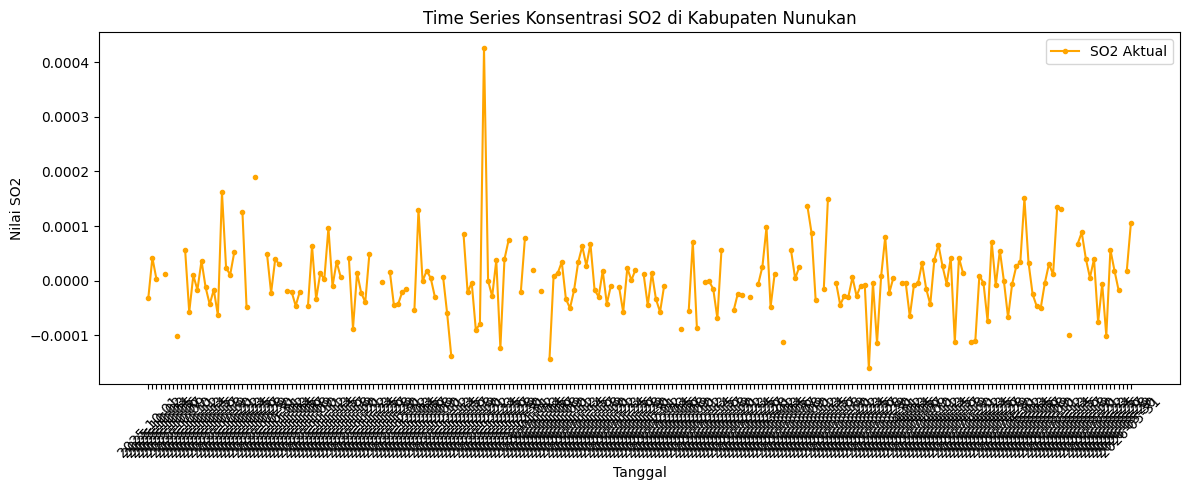

In [1]:
import pandas as pd
import netCDF4
import numpy as np
import matplotlib.pyplot as plt

# --- 1. PROSES EKSTRAKSI DATA ---
file_path = "SO2DiNunukan.nc"
ds = netCDF4.Dataset(file_path)

# Ambil SO2 dan Time
so2 = ds.variables["SO2"][:]
time = ds.variables["t"][:]

# Konversi waktu ke format tanggal
try:
    time_units = ds.variables["t"].units
    dates = netCDF4.num2date(time, units=time_units)
except Exception:
    dates = time  # fallback jika tidak ada units

new_dates = []
new_so2 = [] # Ubah nama variabel agar konsisten

for i in range(len(dates)):
    new_date = dates[i].strftime('%Y-%m-%d')
    new_dates.append(new_date)
    # Ganti no2[i] menjadi so2[i]
    new_so2.append(np.mean(so2[i]))

# Buat DataFrame dan simpan ke CSV
df = pd.DataFrame({
    "date": new_dates,
    "SO2": new_so2
})
df.to_csv("SO2_Nunukan_timeseries.csv", index=False)


# --- 2. PROSES PEMBUATAN GRAFIK ---
plt.figure(figsize=(12, 5)) # Diperlebar agar tanggal tidak terlalu berdempetan

# Plot data tanggal di sumbu X dan nilai SO2 di sumbu Y
plt.plot(df["date"], df["SO2"], label="SO2 Aktual", color="orange", marker=".", linewidth=1.5)

plt.title("Time Series Konsentrasi SO2 di Kabupaten Nunukan")
plt.xlabel("Tanggal")
plt.ylabel("Nilai SO2")

# Merotasi label tanggal di sumbu X agar mudah dibaca dan tidak bertumpuk
plt.xticks(rotation=45)
plt.tight_layout() # Memastikan label bawah tidak terpotong saat ditampilkan

plt.legend()
plt.show()

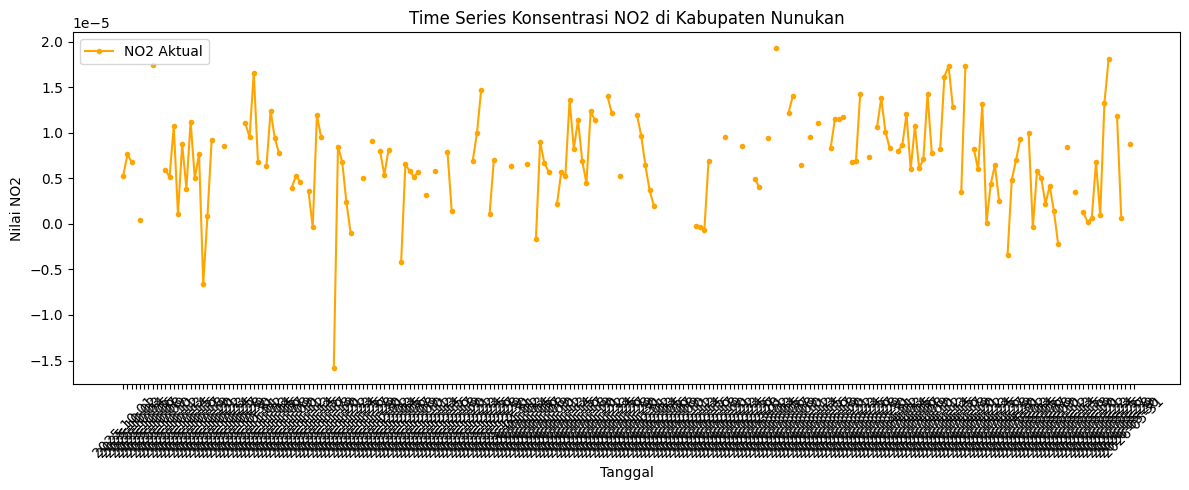

In [3]:
import pandas as pd
import netCDF4
import numpy as np
import matplotlib.pyplot as plt

# --- 1. PROSES EKSTRAKSI DATA ---
file_path = "NO2DiNunukan.nc"
ds = netCDF4.Dataset(file_path)

# Ambil NO2 dan Time
no2 = ds.variables["NO2"][:]
time = ds.variables["t"][:]

# Konversi waktu ke format tanggal
try:
    time_units = ds.variables["t"].units
    dates = netCDF4.num2date(time, units=time_units)
except Exception:
    dates = time  # fallback jika tidak ada units

new_dates = []
new_no2 = [] # Ubah nama variabel agar konsisten

for i in range(len(dates)):
    new_date = dates[i].strftime('%Y-%m-%d')
    new_dates.append(new_date)
    # Ganti no2[i] menjadi so2[i]
    new_no2.append(np.mean(no2[i]))

# Buat DataFrame dan simpan ke CSV
df = pd.DataFrame({
    "date": new_dates,
    "NO2": new_no2
})
df.to_csv("NO2_Nunukan_timeseries.csv", index=False)


# --- 2. PROSES PEMBUATAN GRAFIK ---
plt.figure(figsize=(12, 5)) # Diperlebar agar tanggal tidak terlalu berdempetan

# Plot data tanggal di sumbu X dan nilai NO2 di sumbu Y
plt.plot(df["date"], df["NO2"], label="NO2 Aktual", color="orange", marker=".", linewidth=1.5)

plt.title("Time Series Konsentrasi NO2 di Kabupaten Nunukan")
plt.xlabel("Tanggal")
plt.ylabel("Nilai NO2")

# Merotasi label tanggal di sumbu X agar mudah dibaca dan tidak bertumpuk
plt.xticks(rotation=45)
plt.tight_layout() # Memastikan label bawah tidak terpotong saat ditampilkan

plt.legend()
plt.show()

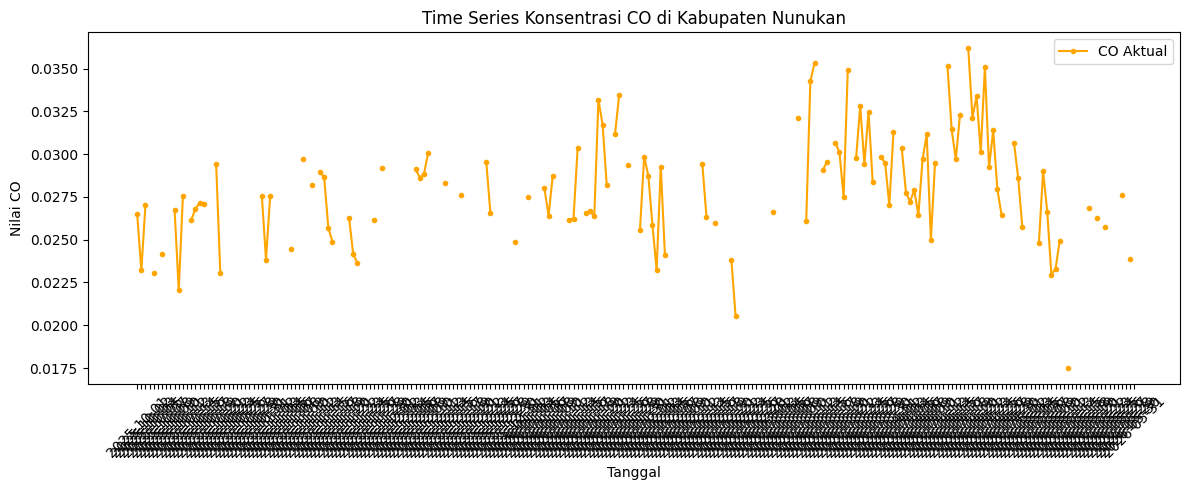

In [5]:
import pandas as pd
import netCDF4
import numpy as np
import matplotlib.pyplot as plt

# --- 1. PROSES EKSTRAKSI DATA ---
file_path = "CODiNunukan.nc"
ds = netCDF4.Dataset(file_path)

# Ambil COD dan Time
co = ds.variables["CO"][:]
time = ds.variables["t"][:]

# Konversi waktu ke format tanggal
try:
    time_units = ds.variables["t"].units
    dates = netCDF4.num2date(time, units=time_units)
except Exception:
    dates = time  # fallback jika tidak ada units

new_dates = []
new_co = [] # Ubah nama variabel agar konsisten

for i in range(len(dates)):
    new_date = dates[i].strftime('%Y-%m-%d')
    new_dates.append(new_date)
    # Ganti no2[i] menjadi so2[i]
    new_co.append(np.mean(co[i]))

# Buat DataFrame dan simpan ke CSV
df = pd.DataFrame({
    "date": new_dates,
    "CO": new_co
})
df.to_csv("CO_Nunukan_timeseries.csv", index=False)


# --- 2. PROSES PEMBUATAN GRAFIK ---
plt.figure(figsize=(12, 5)) # Diperlebar agar tanggal tidak terlalu berdempetan

# Plot data tanggal di sumbu X dan nilai CO di sumbu Y
plt.plot(df["date"], df["CO"], label="CO Aktual", color="orange", marker=".", linewidth=1.5)

plt.title("Time Series Konsentrasi CO di Kabupaten Nunukan")
plt.xlabel("Tanggal")
plt.ylabel("Nilai CO")

# Merotasi label tanggal di sumbu X agar mudah dibaca dan tidak bertumpuk
plt.xticks(rotation=45)
plt.tight_layout() # Memastikan label bawah tidak terpotong saat ditampilkan

plt.legend()
plt.show()

In [12]:
import pandas as pd

df = pd.read_csv("CO_Nunukan_Timeseries.csv")
df['date'] = pd.to_datetime(df['date'])

# Buat rentang tanggal lengkap
start_date = "2025-08-31"
end_date   = "2026-08-31"
full_range = pd.date_range(start=start_date, end=end_date, freq='D')

# Cek tanggal yang hilang
missing_dates = full_range.difference(df['date'])

print(f"Jumlah hari missing: {len(missing_dates)}")
print("Daftar tanggal missing:")
print(missing_dates)

Jumlah hari missing: 3
Daftar tanggal missing:
DatetimeIndex(['2025-10-06', '2026-05-17', '2026-08-31'], dtype='datetime64[ns]', freq=None)


In [26]:
import pandas as pd

df = pd.read_csv("SO2_Nunukan_Timeseries.csv")
df['date'] = pd.to_datetime(df['date'])

# Buat rentang tanggal lengkap
start_date = "2025-08-31"
end_date   = "2026-08-31"
full_range = pd.date_range(start=start_date, end=end_date, freq='D')

# Cek tanggal yang hilang
missing_dates = full_range.difference(df['date'])

print(f"Jumlah hari missing: {len(missing_dates)}")
print("Daftar tanggal missing:")
print(missing_dates)

Jumlah hari missing: 16
Daftar tanggal missing:
DatetimeIndex(['2025-09-20', '2025-09-30', '2025-10-08', '2025-11-23',
               '2025-11-24', '2025-11-25', '2025-11-26', '2025-11-27',
               '2025-11-28', '2025-11-29', '2025-11-30', '2025-12-01',
               '2025-12-02', '2026-04-08', '2026-07-06', '2026-08-31'],
              dtype='datetime64[ns]', freq=None)


In [22]:
import pandas as pd

df = pd.read_csv("NO2_Nunukan_Timeseries.csv")
df['date'] = pd.to_datetime(df['date'])

# Buat rentang tanggal lengkap
start_date = "2025-08-31"
end_date   = "2026-08-31"
full_range = pd.date_range(start=start_date, end=end_date, freq='D')

# Cek tanggal yang hilang
missing_dates = full_range.difference(df['date'])

print(f"Jumlah hari missing: {len(missing_dates)}")
print("Daftar tanggal missing:")
print(missing_dates)

Jumlah hari missing: 4
Daftar tanggal missing:
DatetimeIndex(['2025-10-26', '2026-05-17', '2026-06-23', '2026-08-31'], dtype='datetime64[ns]', freq=None)


In [15]:
df = pd.read_csv("CO_Nunukan_Timeseries.csv")
missing_value = df['CO'].isna().sum()
print(missing_value)

166


In [21]:
df = pd.read_csv("NO2_Nunukan_Timeseries.csv")
missing_value = df['NO2'].isna().sum()
print(missing_value)

124


In [24]:
df = pd.read_csv("SO2_Nunukan_Timeseries.csv")
missing_value = df['SO2'].isna().sum()
print(missing_value)

55


In [31]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

df = pd.read_csv("CO_Nunukan_Timeseries_imputed.csv")
df_clean = df.dropna(subset=['CO']).copy()

df_clean['date'] = pd.to_datetime(df_clean['date'])
df_clean = df_clean.sort_values('date').reset_index(drop=True)

model = IsolationForest(contamination=0.05, random_state=42)  # contamination 0.05 = 5%
pred = model.fit_predict(df_clean[['CO']])

# Tambahkan hasil prediksi ke dataframe
df_clean['anomaly'] = pred  # -1 = outlier, 1 = normal

# Nilai -1 merepresentasikan outlier
outliers_if = df_clean[df_clean['anomaly'] == -1]
jumlah_outlier = len(outliers_if)
print("Jumlah outlier:", jumlah_outlier)
print(outliers_if[['date', 'CO']].head())

Jumlah outlier: 19
          date        CO
176 2026-02-23  0.020537
256 2026-05-14  0.017498
257 2026-05-15  0.019061
258 2026-05-16  0.020624
301 2026-06-28  0.019963


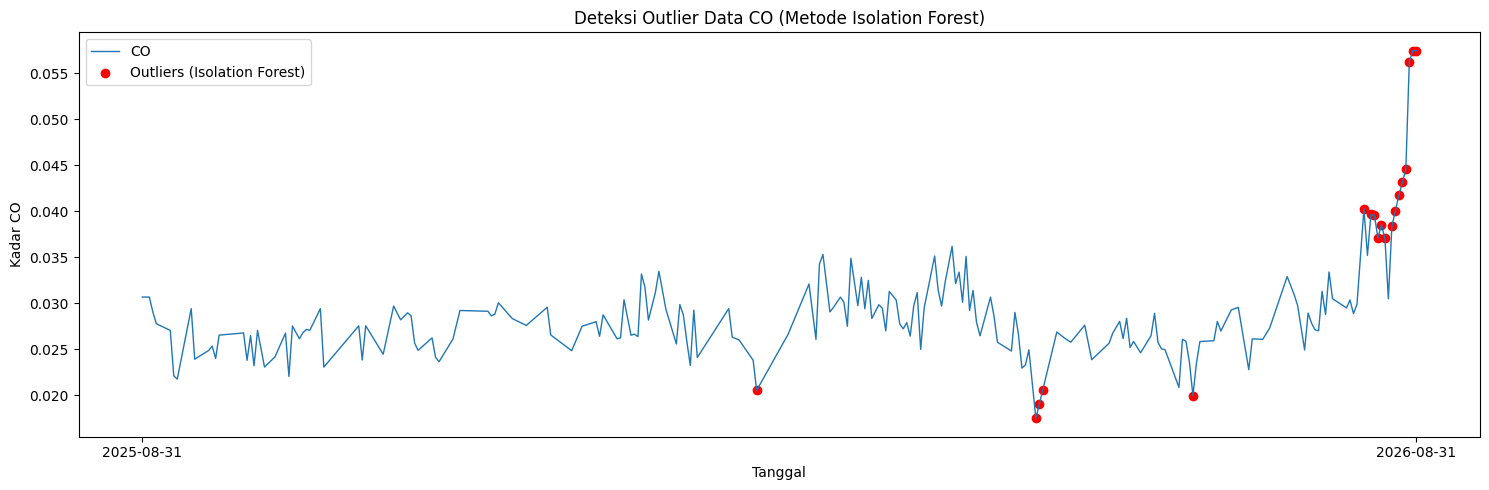

In [32]:
# Visualisasi
plt.figure(figsize=(15, 5))
plt.plot(df_clean['date'], df_clean['CO'], label="CO", linewidth=1)
plt.scatter(outliers_if['date'], outliers_if['CO'],
            color='red', marker='o', label="Outliers (Isolation Forest)")
plt.title("Deteksi Outlier Data CO (Metode Isolation Forest)")
plt.xlabel("Tanggal")
plt.ylabel("Kadar CO")
plt.legend()
plt.tight_layout()
plt.xticks(
    ticks=[df_clean['date'].iloc[0], df_clean['date'].iloc[-1]],
    labels=[df_clean['date'].iloc[0].strftime('%Y-%m-%d'),
            df_clean['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.show()

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

df = pd.read_csv("SO2_Nunukan_Timeseries_imputed.csv")
df_clean = df.dropna(subset=['SO2']).copy()

df_clean['date'] = pd.to_datetime(df_clean['date'])
df_clean = df_clean.sort_values('date').reset_index(drop=True)

model = IsolationForest(contamination=0.05, random_state=42)  # contamination 0.05 = 5%
pred = model.fit_predict(df_clean[['SO2']])

# Tambahkan hasil prediksi ke dataframe
df_clean['anomaly'] = pred  # -1 = outlier, 1 = normal

# Nilai -1 merepresentasikan outlier
outliers_if = df_clean[df_clean['anomaly'] == -1]
jumlah_outlier = len(outliers_if)
print("Jumlah outlier:", jumlah_outlier)
print(outliers_if[['date', 'SO2']].head())

Jumlah outlier: 19
         date       SO2
8  2025-09-08 -0.000223
16 2025-09-16  0.000154
17 2025-09-17  0.000168
18 2025-09-18  0.000182
50 2025-10-20  0.000162


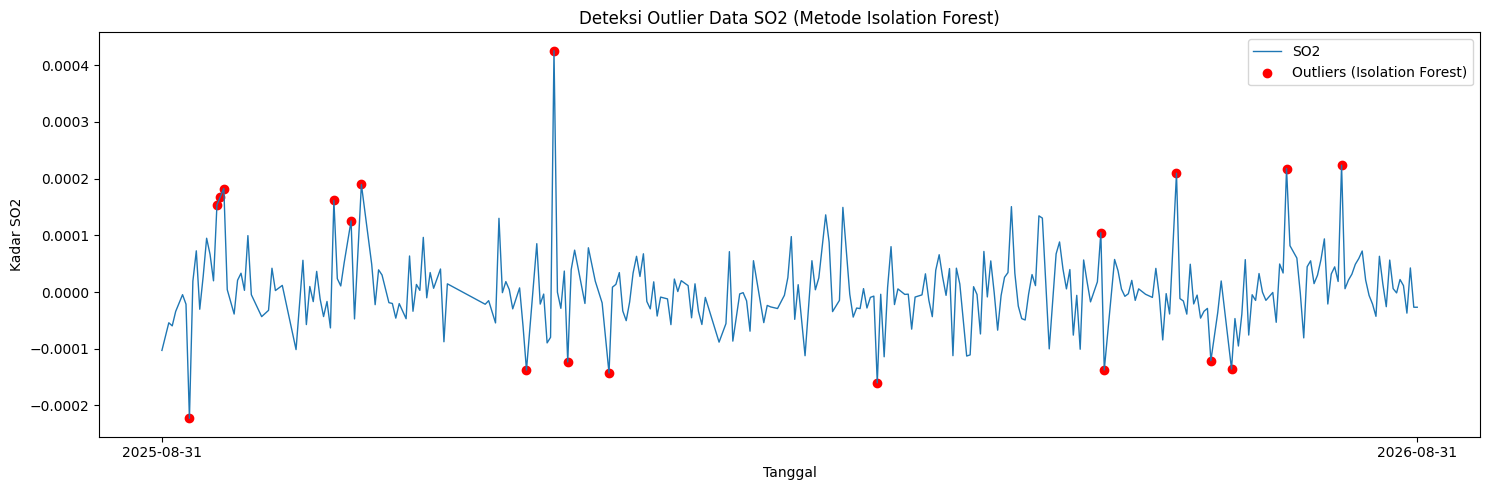

In [34]:
# Visualisasi
plt.figure(figsize=(15, 5))
plt.plot(df_clean['date'], df_clean['SO2'], label="SO2", linewidth=1)
plt.scatter(outliers_if['date'], outliers_if['SO2'],
            color='red', marker='o', label="Outliers (Isolation Forest)")
plt.title("Deteksi Outlier Data SO2 (Metode Isolation Forest)")
plt.xlabel("Tanggal")
plt.ylabel("Kadar SO2")
plt.legend()
plt.tight_layout()
plt.xticks(
    ticks=[df_clean['date'].iloc[0], df_clean['date'].iloc[-1]],
    labels=[df_clean['date'].iloc[0].strftime('%Y-%m-%d'),
            df_clean['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.show()

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

df = pd.read_csv("NO2_Nunukan_Timeseries_imputed.csv")
df_clean = df.dropna(subset=['NO2']).copy()

df_clean['date'] = pd.to_datetime(df_clean['date'])
df_clean = df_clean.sort_values('date').reset_index(drop=True)

model = IsolationForest(contamination=0.05, random_state=42)  # contamination 0.05 = 5%
pred = model.fit_predict(df_clean[['NO2']])

# Tambahkan hasil prediksi ke dataframe
df_clean['anomaly'] = pred  # -1 = outlier, 1 = normal

# Nilai -1 merepresentasikan outlier
outliers_if = df_clean[df_clean['anomaly'] == -1]
jumlah_outlier = len(outliers_if)
print("Jumlah outlier:", jumlah_outlier)
print(outliers_if[['date', 'NO2']].head())

Jumlah outlier: 19
         date       NO2
4  2025-09-04 -0.000002
38 2025-10-08  0.000017
50 2025-10-20 -0.000007
63 2025-11-02  0.000017
81 2025-11-20 -0.000007


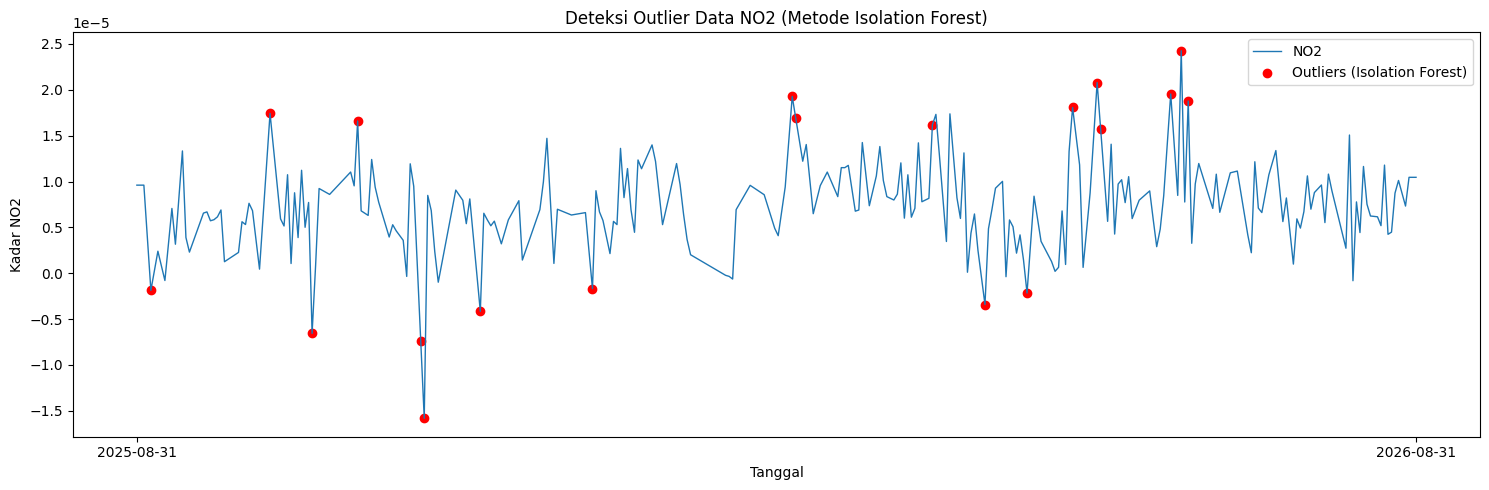

In [36]:
# Visualisasi
plt.figure(figsize=(15, 5))
plt.plot(df_clean['date'], df_clean['NO2'], label="NO2", linewidth=1)
plt.scatter(outliers_if['date'], outliers_if['NO2'],
            color='red', marker='o', label="Outliers (Isolation Forest)")
plt.title("Deteksi Outlier Data NO2 (Metode Isolation Forest)")
plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")
plt.legend()
plt.tight_layout()
plt.xticks(
    ticks=[df_clean['date'].iloc[0], df_clean['date'].iloc[-1]],
    labels=[df_clean['date'].iloc[0].strftime('%Y-%m-%d'),
            df_clean['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.show()

In [23]:
import pandas as pd

df = pd.read_csv("SO2_Nunukan_Timeseries.csv")
df['date'] = pd.to_datetime(df['date'])

# Buat rentang tanggal lengkap
start_date = "2025-08-31"
end_date   = "2026-08-31"
full_range = pd.date_range(start=start_date, end=end_date, freq='D')

# Reindex ke rentang tanggal lengkap (tanggal yang hilang jadi NaN)
df = df.set_index('date').reindex(full_range)
df.index.name = 'date'

# Simpan info baris mana saja yang awalnya missing (buat dokumentasi/laporan)
missing_mask = df.isna().any(axis=1)
print(f"Jumlah hari missing sebelum imputasi: {missing_mask.sum()}")

# --- Imputasi ---
# Kolom numerik yang mau diimputasi (sesuaikan dengan nama kolom asli, misal 'SO2', 'CO', 'NO2', dst)
numeric_cols = df.select_dtypes(include='number').columns

# 1. Interpolasi linear berbasis waktu untuk gap di tengah data
df[numeric_cols] = df[numeric_cols].interpolate(method='time', limit_direction='both')

# 2. Fallback: kalau masih ada NaN di ujung deret (misal tanggal terakhir 31 Agu 2026
#    tidak punya data sesudahnya untuk diinterpolasi), isi dengan forward-fill lalu backward-fill
df[numeric_cols] = df[numeric_cols].ffill().bfill()

# Cek ulang missing value
print(f"Jumlah hari missing setelah imputasi: {df[numeric_cols].isna().sum().sum()}")

# Reset index biar kolom 'date' kembali jadi kolom biasa
df = df.reset_index()

# Simpan hasil
df.to_csv("SO2_Nunukan_Timeseries_imputed.csv", index=False)
print("Selesai. File disimpan sebagai SO2_Nunukan_Timeseries_imputed.csv")

Jumlah hari missing sebelum imputasi: 71
Jumlah hari missing setelah imputasi: 0
Selesai. File disimpan sebagai SO2_Nunukan_Timeseries_imputed.csv


In [27]:
import pandas as pd

df = pd.read_csv("NO2_Nunukan_Timeseries.csv")
df['date'] = pd.to_datetime(df['date'])

# Buat rentang tanggal lengkap
start_date = "2025-08-31"
end_date   = "2026-08-31"
full_range = pd.date_range(start=start_date, end=end_date, freq='D')

# Reindex ke rentang tanggal lengkap (tanggal yang hilang jadi NaN)
df = df.set_index('date').reindex(full_range)
df.index.name = 'date'

# Simpan info baris mana saja yang awalnya missing (buat dokumentasi/laporan)
missing_mask = df.isna().any(axis=1)
print(f"Jumlah hari missing sebelum imputasi: {missing_mask.sum()}")

# --- Imputasi ---
# Kolom numerik yang mau diimputasi (sesuaikan dengan nama kolom asli, misal 'SO2', 'CO', 'NO2', dst)
numeric_cols = df.select_dtypes(include='number').columns

# 1. Interpolasi linear berbasis waktu untuk gap di tengah data
df[numeric_cols] = df[numeric_cols].interpolate(method='time', limit_direction='both')

# 2. Fallback: kalau masih ada NaN di ujung deret (misal tanggal terakhir 31 Agu 2026
#    tidak punya data sesudahnya untuk diinterpolasi), isi dengan forward-fill lalu backward-fill
df[numeric_cols] = df[numeric_cols].ffill().bfill()

# Cek ulang missing value
print(f"Jumlah hari missing setelah imputasi: {df[numeric_cols].isna().sum().sum()}")

# Reset index biar kolom 'date' kembali jadi kolom biasa
df = df.reset_index()

# Simpan hasil
df.to_csv("NO2_Nunukan_Timeseries_imputed.csv", index=False)
print("Selesai. File disimpan sebagai NO2_Nunukan_Timeseries_imputed.csv")

Jumlah hari missing sebelum imputasi: 128
Jumlah hari missing setelah imputasi: 0
Selesai. File disimpan sebagai NO2_Nunukan_Timeseries_imputed.csv


In [28]:
import pandas as pd

df = pd.read_csv("CO_Nunukan_Timeseries.csv")
df['date'] = pd.to_datetime(df['date'])

# Buat rentang tanggal lengkap
start_date = "2025-08-31"
end_date   = "2026-08-31"
full_range = pd.date_range(start=start_date, end=end_date, freq='D')

# Reindex ke rentang tanggal lengkap (tanggal yang hilang jadi NaN)
df = df.set_index('date').reindex(full_range)
df.index.name = 'date'

# Simpan info baris mana saja yang awalnya missing (buat dokumentasi/laporan)
missing_mask = df.isna().any(axis=1)
print(f"Jumlah hari missing sebelum imputasi: {missing_mask.sum()}")

# --- Imputasi ---
# Kolom numerik yang mau diimputasi (sesuaikan dengan nama kolom asli, misal 'SO2', 'CO', 'NO2', dst)
numeric_cols = df.select_dtypes(include='number').columns

# 1. Interpolasi linear berbasis waktu untuk gap di tengah data
df[numeric_cols] = df[numeric_cols].interpolate(method='time', limit_direction='both')

# 2. Fallback: kalau masih ada NaN di ujung deret (misal tanggal terakhir 31 Agu 2026
#    tidak punya data sesudahnya untuk diinterpolasi), isi dengan forward-fill lalu backward-fill
df[numeric_cols] = df[numeric_cols].ffill().bfill()

# Cek ulang missing value
print(f"Jumlah hari missing setelah imputasi: {df[numeric_cols].isna().sum().sum()}")

# Reset index biar kolom 'date' kembali jadi kolom biasa
df = df.reset_index()

# Simpan hasil
df.to_csv("CO_Nunukan_Timeseries_imputed.csv", index=False)
print("Selesai. File disimpan sebagai CO_Nunukan_Timeseries_imputed.csv")

Jumlah hari missing sebelum imputasi: 169
Jumlah hari missing setelah imputasi: 0
Selesai. File disimpan sebagai CO_Nunukan_Timeseries_imputed.csv


In [74]:
import pandas as pd

df_co = pd.read_csv("CO_Nunukan_Timeseries.csv")
df_no2 = pd.read_csv("NO2_Nunukan_Timeseries.csv")
df_so2 = pd.read_csv("SO2_Nunukan_Timeseries.csv")

dataframe_merged = pd.DataFrame({
    "date": df_co['date'],
    "CO": df_co['CO'],
    "NO2": df_no2['NO2'],
    "SO2": df_so2['SO2']
})

dataframe_merged.to_csv("Polutan_Nunukan.csv", index=False)

Jumlah outlier: 19
         date       NO2
4  2025-09-04 -0.000002
38 2025-10-08  0.000017
50 2025-10-20 -0.000007
63 2025-11-02  0.000017
81 2025-11-20 -0.000007


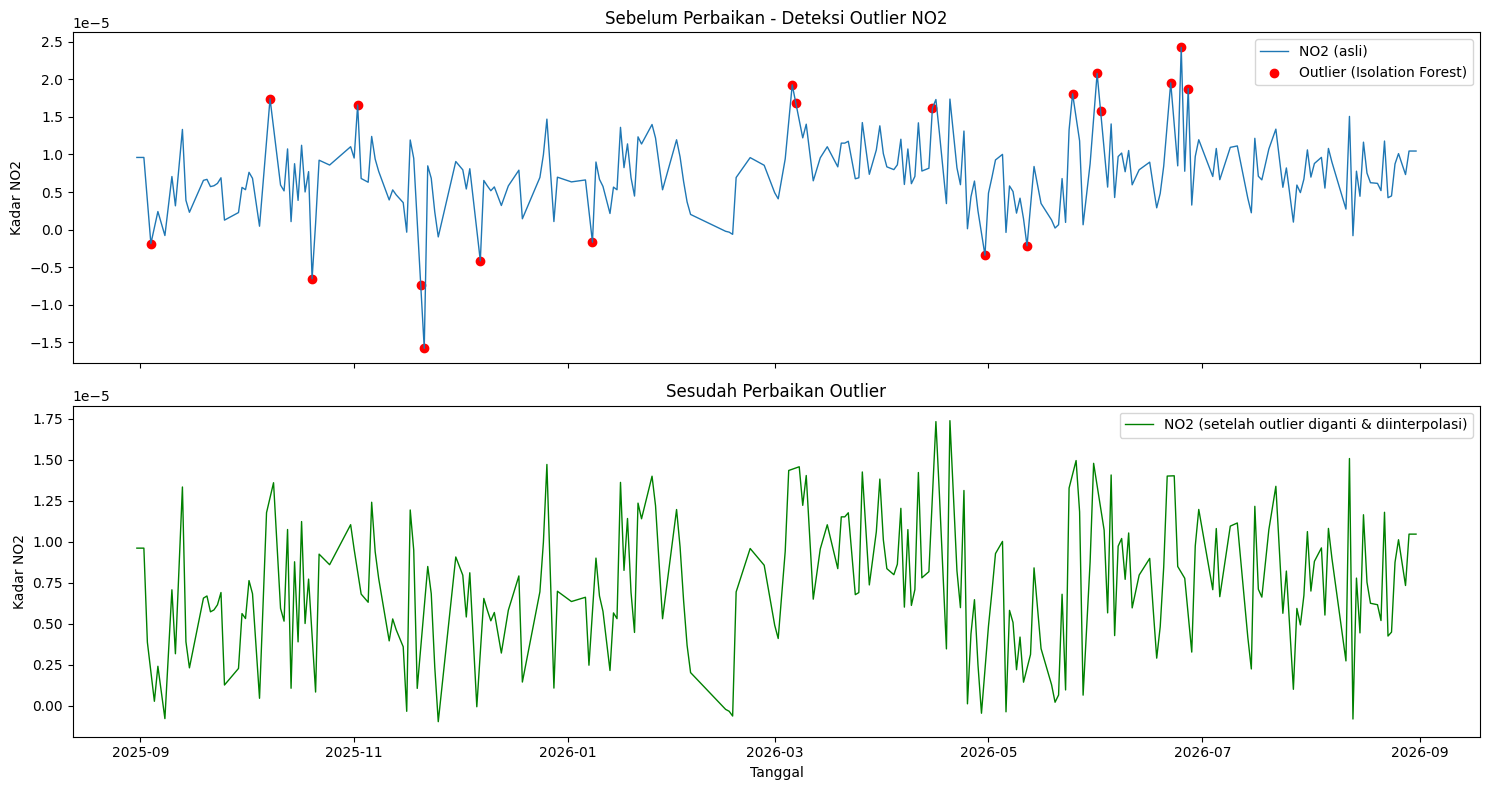

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# 1. Load data
df = pd.read_csv("NO2_Nunukan_Timeseries_imputed.csv")
df_clean = df.dropna(subset=['NO2']).copy()

df_clean['date'] = pd.to_datetime(df_clean['date'])
df_clean = df_clean.sort_values('date').reset_index(drop=True)

# 2. Deteksi outlier dengan Isolation Forest
model = IsolationForest(contamination=0.05, random_state=42)
pred = model.fit_predict(df_clean[['NO2']])
df_clean['anomaly'] = pred  # -1 = outlier, 1 = normal

outliers_if = df_clean[df_clean['anomaly'] == -1]
print("Jumlah outlier:", len(outliers_if))
print(outliers_if[['date', 'NO2']].head())

# 3. PERBAIKAN OUTLIER: ganti nilai outlier jadi NaN, lalu interpolasi
df_fixed = df_clean.copy()
df_fixed.loc[df_fixed['anomaly'] == -1, 'NO2'] = np.nan
df_fixed['NO2'] = df_fixed['NO2'].interpolate(method='linear').ffill().bfill()

# 4. Visualisasi sebelum vs sesudah
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

axes[0].plot(df_clean['date'], df_clean['NO2'], label="NO2 (asli)", linewidth=1)
axes[0].scatter(outliers_if['date'], outliers_if['NO2'],
                 color='red', marker='o', label="Outlier (Isolation Forest)")
axes[0].set_title("Sebelum Perbaikan - Deteksi Outlier NO2")
axes[0].set_ylabel("Kadar NO2")
axes[0].legend()

axes[1].plot(df_fixed['date'], df_fixed['NO2'], color='green', linewidth=1,
             label="NO2 (setelah outlier diganti & diinterpolasi)")
axes[1].set_title("Sesudah Perbaikan Outlier")
axes[1].set_xlabel("Tanggal")
axes[1].set_ylabel("Kadar NO2")
axes[1].legend()

plt.tight_layout()
plt.show()

# 5. Simpan hasil
df_fixed[['date', 'NO2']].to_csv("NO2_Nunukan_Timeseries_fixed.csv", index=False)

Jumlah outlier: 19
         date       SO2
8  2025-09-08 -0.000223
16 2025-09-16  0.000154
17 2025-09-17  0.000168
18 2025-09-18  0.000182
50 2025-10-20  0.000162


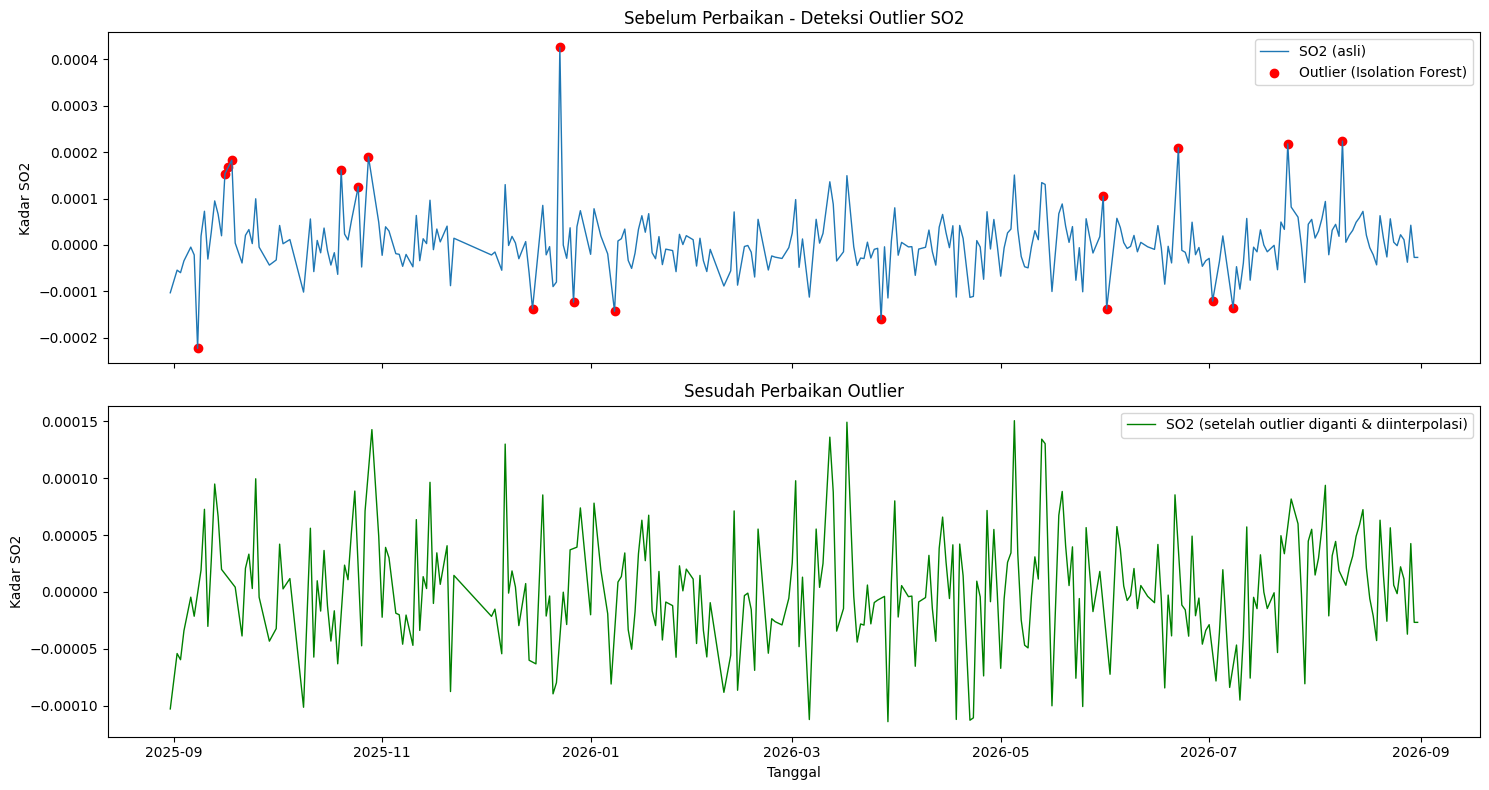

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# 1. Load data
df = pd.read_csv("SO2_Nunukan_Timeseries_imputed.csv")
df_clean = df.dropna(subset=['SO2']).copy()

df_clean['date'] = pd.to_datetime(df_clean['date'])
df_clean = df_clean.sort_values('date').reset_index(drop=True)

# 2. Deteksi outlier dengan Isolation Forest
model = IsolationForest(contamination=0.05, random_state=42)
pred = model.fit_predict(df_clean[['SO2']])
df_clean['anomaly'] = pred  # -1 = outlier, 1 = normal

outliers_if = df_clean[df_clean['anomaly'] == -1]
print("Jumlah outlier:", len(outliers_if))
print(outliers_if[['date', 'SO2']].head())

# 3. PERBAIKAN OUTLIER: ganti nilai outlier jadi NaN, lalu interpolasi
df_fixed = df_clean.copy()
df_fixed.loc[df_fixed['anomaly'] == -1, 'SO2'] = np.nan
df_fixed['SO2'] = df_fixed['SO2'].interpolate(method='linear').ffill().bfill()

# 4. Visualisasi sebelum vs sesudah
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

axes[0].plot(df_clean['date'], df_clean['SO2'], label="SO2 (asli)", linewidth=1)
axes[0].scatter(outliers_if['date'], outliers_if['SO2'],
                 color='red', marker='o', label="Outlier (Isolation Forest)")
axes[0].set_title("Sebelum Perbaikan - Deteksi Outlier SO2")
axes[0].set_ylabel("Kadar SO2")
axes[0].legend()

axes[1].plot(df_fixed['date'], df_fixed['SO2'], color='green', linewidth=1,
             label="SO2 (setelah outlier diganti & diinterpolasi)")
axes[1].set_title("Sesudah Perbaikan Outlier")
axes[1].set_xlabel("Tanggal")
axes[1].set_ylabel("Kadar SO2")
axes[1].legend()

plt.tight_layout()
plt.show()

# 5. Simpan hasil
df_fixed[['date', 'SO2']].to_csv("SO2_Nunukan_Timeseries_fixed.csv", index=False)

Jumlah outlier: 19
          date        CO
176 2026-02-23  0.020537
256 2026-05-14  0.017498
257 2026-05-15  0.019061
258 2026-05-16  0.020624
301 2026-06-28  0.019963


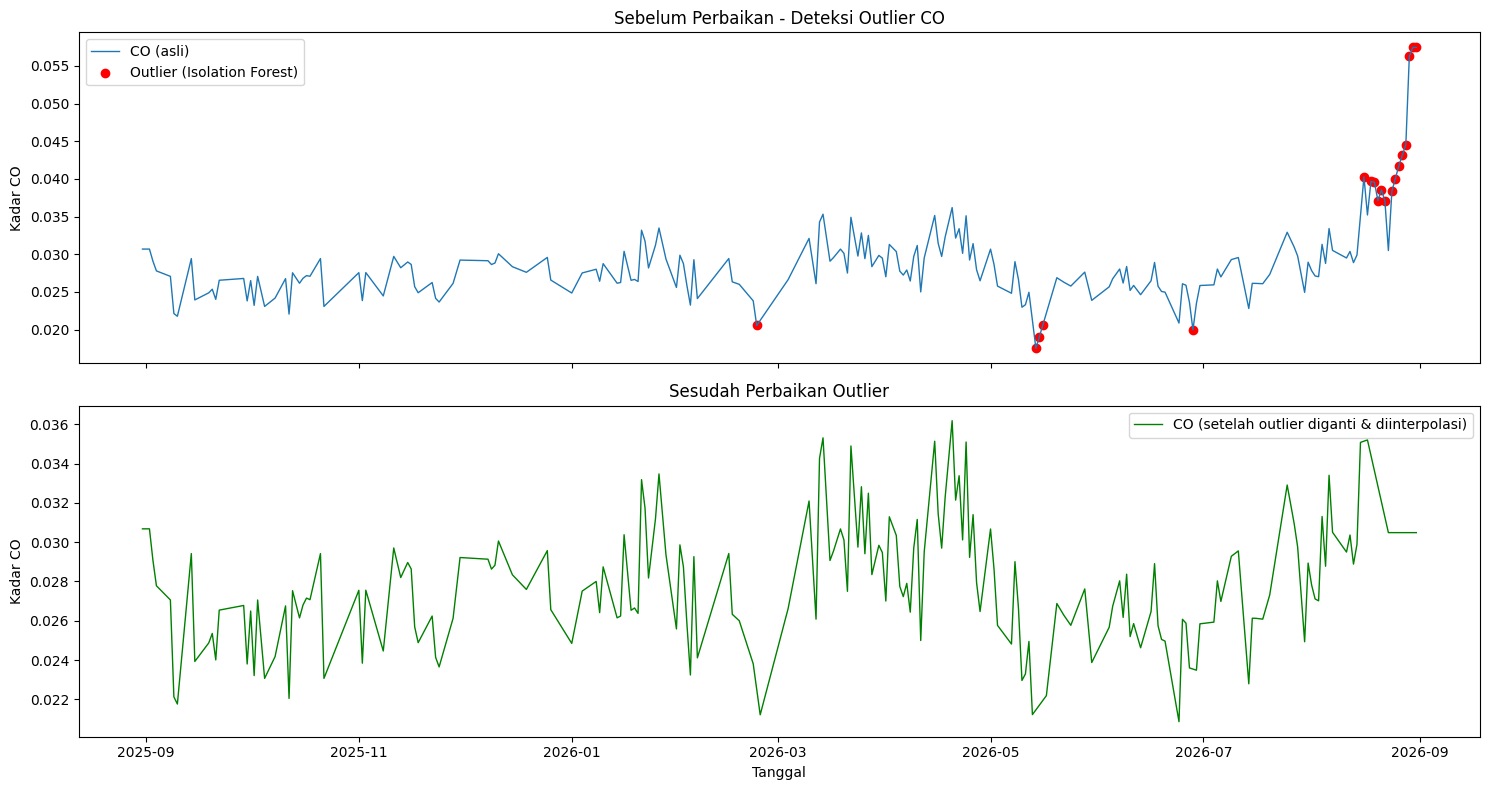

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# 1. Load data
df = pd.read_csv("CO_Nunukan_Timeseries_imputed.csv")
df_clean = df.dropna(subset=['CO']).copy()

df_clean['date'] = pd.to_datetime(df_clean['date'])
df_clean = df_clean.sort_values('date').reset_index(drop=True)

# 2. Deteksi outlier dengan Isolation Forest
model = IsolationForest(contamination=0.05, random_state=42)
pred = model.fit_predict(df_clean[['CO']])
df_clean['anomaly'] = pred  # -1 = outlier, 1 = normal

outliers_if = df_clean[df_clean['anomaly'] == -1]
print("Jumlah outlier:", len(outliers_if))
print(outliers_if[['date', 'CO']].head())

# 3. PERBAIKAN OUTLIER: ganti nilai outlier jadi NaN, lalu interpolasi
df_fixed = df_clean.copy()
df_fixed.loc[df_fixed['anomaly'] == -1, 'CO'] = np.nan
df_fixed['CO'] = df_fixed['CO'].interpolate(method='linear').ffill().bfill()

# 4. Visualisasi sebelum vs sesudah
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

axes[0].plot(df_clean['date'], df_clean['CO'], label="CO (asli)", linewidth=1)
axes[0].scatter(outliers_if['date'], outliers_if['CO'],
                 color='red', marker='o', label="Outlier (Isolation Forest)")
axes[0].set_title("Sebelum Perbaikan - Deteksi Outlier CO")
axes[0].set_ylabel("Kadar CO")
axes[0].legend()

axes[1].plot(df_fixed['date'], df_fixed['CO'], color='green', linewidth=1,
             label="CO (setelah outlier diganti & diinterpolasi)")
axes[1].set_title("Sesudah Perbaikan Outlier")
axes[1].set_xlabel("Tanggal")
axes[1].set_ylabel("Kadar CO")
axes[1].legend()

plt.tight_layout()
plt.show()

# 5. Simpan hasil
df_fixed[['date', 'CO']].to_csv("CO_Nunukan_Timeseries_fixed.csv", index=False)

In [6]:
import pandas as pd
import numpy as np
import inspect
import tsfel.feature_extraction.features as tsfel_features

# ---------- 1. Muat dan bersihkan data ----------
df = pd.read_csv('NO2_Nunukan_Timeseries_fixed.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

target_pollutant = 'NO2'

# --- FIX: paksa kolom target jadi numerik, nilai yang gagal dikonversi -> NaN ---
df[target_pollutant] = pd.to_numeric(df[target_pollutant], errors='coerce')

n_missing_before = df[target_pollutant].isna().sum()
print(f"Jumlah nilai non-numerik/kosong yang dikonversi jadi NaN: {n_missing_before}")

Q1 = df[target_pollutant].quantile(0.25)
Q3 = df[target_pollutant].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df.loc[(df[target_pollutant] < lower_bound) | (df[target_pollutant] > upper_bound), target_pollutant] = np.nan

df_clean = df.set_index('date').interpolate(method='time').ffill().bfill()

fs = 1
signal_1d = df_clean[target_pollutant].astype(float).values

# ---------- 2. Daftar PERSIS fitur yang diminta ----------
FEATURE_LIST = """abs_energy auc autocorr average_power calc_centroid calc_max calc_mean
calc_median calc_min calc_std calc_var dfa distance ecdf ecdf_percentile ecdf_percentile_count
ecdf_slope entropy fundamental_frequency higuchi_fractal_dimension hist_mode human_range_energy
hurst_exponent interq_range kurtosis lempel_ziv lpcc max_frequency max_power_spectrum
maximum_fractal_length mean_abs_deviation mean_abs_diff mean_diff median_abs_deviation
median_abs_diff median_diff median_frequency mfcc mse negative_turning neighbourhood_peaks
petrosian_fractal_dimension pk_pk_distance positive_turning power_bandwidth rms skewness slope
spectral_centroid spectral_decrease spectral_distance spectral_entropy spectral_kurtosis
spectral_positive_turning spectral_roll_off spectral_roll_on spectral_skewness spectral_slope
spectral_spread spectral_variation spectrogram_mean_coeff sum_abs_diff wavelet_abs_mean
wavelet_energy wavelet_entropy wavelet_std wavelet_var zero_cross""".split()

print("Jumlah fitur yang diminta:", len(FEATURE_LIST))


def to_scalar(result):
    if isinstance(result, dict) and "values" in result:
        result = result["values"]
    if isinstance(result, (list, tuple, np.ndarray)):
        arr = np.asarray(result, dtype=float)
        return float(np.nanmean(arr))
    return float(result)


def extract_one(fn_name, signal, fs):
    fn = getattr(tsfel_features, fn_name)
    params = inspect.signature(fn).parameters
    if "fs" in params:
        result = fn(signal, fs)
    else:
        result = fn(signal)
    return to_scalar(result)


row = {}
for fn_name in FEATURE_LIST:
    row[fn_name] = extract_one(fn_name, signal_1d, fs)

extracted_features_final = pd.DataFrame([row])

print(f"Berhasil! Jumlah fitur yang dihasilkan untuk {target_pollutant}: {extracted_features_final.shape[1]}")
extracted_features_final.to_csv(f'{target_pollutant}_Nunukan_TSFEL.csv', index=False)

Jumlah nilai non-numerik/kosong yang dikonversi jadi NaN: 0
Jumlah fitur yang diminta: 68
Berhasil! Jumlah fitur yang dihasilkan untuk NO2: 68
